In [1]:
pip install nltk textblob pandas matplotlib seaborn

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
    --------------------------------------- 10.2/625.0 kB ? eta -:--:--
   - ------------------------------------- 30.7/625.0 kB 435.7 kB/s eta 0:00:02
   ---- ---------------------------------- 71.7/625.0 kB 558.5 kB/s eta 0:00:01
   ------- ------------------------------ 122.9/625.0 kB 717.5 kB/s eta 0:00:01
   --------- ---------------------------- 153.6/625.0 kB 762.6 kB/s eta 0:00:01
   ------------- ------------------------ 225.3/625.0 kB 860.2 kB/s eta 0:00:01
   ----------------- -------------------- 286.7/625.0 kB 930.9 kB/s eta 0:00:01
   ---------------------- ----------------- 358.4/625.0 kB 1.0 MB/s eta 0:00:01
   -------------------------- ------------- 419.8/625.0 kB 1.0 MB/s eta 0:00:01
   ------------------------------ --------- 481.3/625.0 kB 1.1 MB/s eta 0:00:01
   ----------------------------------- ---- 553.0/625.0 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------  624.6/625.0 k

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\shifa\AppData\Roaming\nltk_data...


=== SENTIMENT DISTRIBUTION ===
Sentiment
Neutral     14
Positive     4
Negative     2
Name: count, dtype: int64

=== SAMPLE CLASSIFIED ENTRIES ===
                           Article Title  Compound_Score Sentiment
0                         Grace Coolidge          0.4215  Positive
1                         Grace Coolidge          0.4215  Positive
2        First Lady of the United States          0.4215  Positive
3                        Calvin Coolidge          0.0000   Neutral
4                    Burlington, Vermont          0.0000   Neutral
5                  University of Vermont          0.0000   Neutral
6             Northampton, Massachusetts          0.0000   Neutral
7  Clarke Schools for Hearing and Speech          0.0000   Neutral
8                       Washington, D.C.          0.0000   Neutral
9    Vice President of the United States          0.4215  Positive


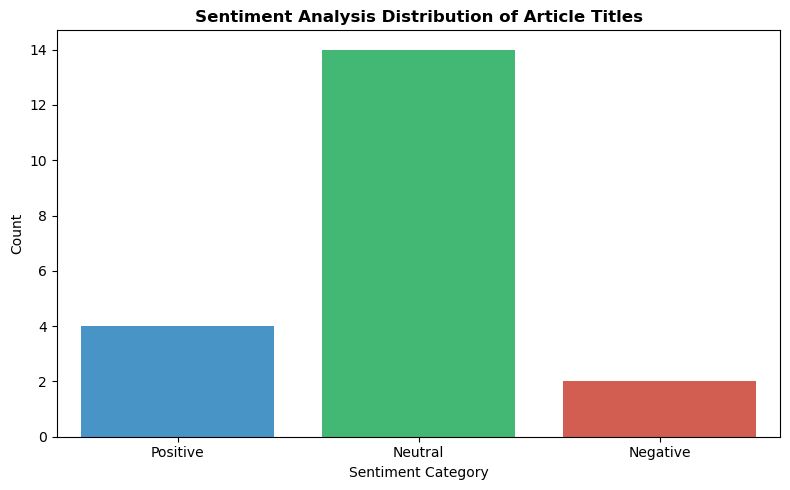

Task 4 Complete! Saved outputs to 'sentiment_analyzed_wikipedia_data.csv'.


In [2]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

# Download VADER lexicon for NLTK
nltk.download('vader_lexicon')

# 1. Load the dataset from Task 2/3
df = pd.read_csv("eda_cleaned_wikipedia_data.csv")

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# 2. Function to compute sentiment scores
def get_sentiment(text):
    scores = sia.polarity_scores(str(text))
    compound = scores['compound']
    
    # Classify based on compound score thresholds
    if compound >= 0.05:
        sentiment = 'Positive'
    elif compound <= -0.05:
        sentiment = 'Negative'
    else:
        sentiment = 'Neutral'
        
    return pd.Series([compound, sentiment], index=['Compound_Score', 'Sentiment'])

# 3. Apply Sentiment Analysis to Article Titles
df[['Compound_Score', 'Sentiment']] = df['Article Title'].apply(get_sentiment)

# 4. Display Results Summary
print("=== SENTIMENT DISTRIBUTION ===")
print(df['Sentiment'].value_counts())
print("\n=== SAMPLE CLASSIFIED ENTRIES ===")
print(df[['Article Title', 'Compound_Score', 'Sentiment']].head(10))

# 5. Visualize Sentiment Breakdown
plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment', data=df, palette=['#3498db', '#2ecc71', '#e74c3c'])
plt.title('Sentiment Analysis Distribution of Article Titles', fontsize=12, fontweight='bold')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("task4_sentiment_distribution.png", dpi=300)
plt.show()

# 6. Save Final Output
df.to_csv("sentiment_analyzed_wikipedia_data.csv", index=False)
print("Task 4 Complete! Saved outputs to 'sentiment_analyzed_wikipedia_data.csv'.")